Dataset Dimensions: (38576, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   address_state          38576 non-null  object 
 2   application_type       38576 non-null  object 
 3   emp_length             38576 non-null  object 
 4   emp_title              37138 non-null  object 
 5   grade                  38576 non-null  object 
 6   home_ownership         38576 non-null  object 
 7   issue_date             38576 non-null  object 
 8   last_credit_pull_date  38576 non-null  object 
 9   last_payment_date      38576 non-null  object 
 10  loan_status            38576 non-null  object 
 11  next_payment_date      38576 non-null  object 
 12  member_id              38576 non-null  int64  
 13  purpose                38576 non-null  object 
 14  sub_grade             

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


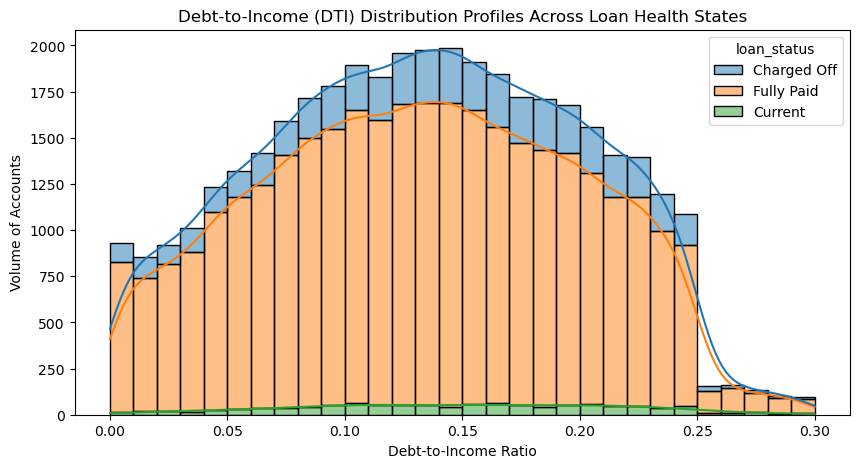

   emp_length home_ownership  Average_Loan_Val  Total_Defaults  \
30    7 years          OTHER      10000.000000               1   
13    3 years          OTHER       9980.000000               3   
1      1 year          OTHER      12880.000000               4   
5   10+ years          OTHER      11013.157895               5   
22    5 years          OTHER       9960.000000               1   
9     2 years          OTHER      12040.000000               2   
7   10+ years           RENT      12224.342105             469   
27    6 years            OWN      10569.254658              27   
32    7 years           RENT      11278.322148             122   
31    7 years            OWN      10235.535714              22   

    Total_Accounts  Default_Rate  
30               3     33.333333  
13              10     30.000000  
1               15     26.666667  
5               19     26.315789  
22               5     20.000000  
9               10     20.000000  
7             2546     18.42

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ingest clean data from staging layer
df = pd.read_excel('financial_loan.xlsx')

# 2. Check shapes and structural variables
print(f"Dataset Dimensions: {df.shape}")
print(df.info())

# 3. Mathematical Assessment: Risk Profile Distributions
# Evaluate internal banking risk matrices across key continuous metrics
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='dti', hue='loan_status', kde=True, bins=30, multiple="stack")
plt.title('Debt-to-Income (DTI) Distribution Profiles Across Loan Health States')
plt.xlabel('Debt-to-Income Ratio')
plt.ylabel('Volume of Accounts')
plt.savefig('dti_distribution.png')
plt.show()

# 4. MBA Business Analytics Domain Focus: Multi-Variable Demographic Evaluation
# Correlating employee duration metrics with average funding allocations and risk rates
demographic_pivot = df.groupby(['emp_length', 'home_ownership']).agg(
    Average_Loan_Val=('loan_amount', 'mean'),
    Total_Defaults=('loan_status', lambda x: (x == 'Charged Off').sum()),
    Total_Accounts=('id', 'count')
).reset_index()

demographic_pivot['Default_Rate'] = (demographic_pivot['Total_Defaults'] / demographic_pivot['Total_Accounts']) * 100
print(demographic_pivot.sort_values(by='Default_Rate', ascending=False).head(10))